# Filleted Infinite Potential Well

This notebook presents a complete solution to the 1D Schrödinger equation for a particle confined in a symmetric potential well with **circular-arc filleted corners**. We explore four complementary methods:

| Method | Type | Tool |
|--------|------|------|
| **Perturbation Theory** | Analytical (1st order) | Simpson quadrature |
| **Variational Method** | Semi-analytical | catkit root-finding |
| **Shooting Method** | Numerical ODE | catkit RK4 + bisection |
| **Finite Difference** | Numerical matrix | scipy eigh_tridiagonal |

### Parameters
- $\alpha$ — half-width of the rectangular section
- $\beta$ — depth of the well
- $\gamma$ — corner rounding (fillet) radius

All quantities are expressed in **dimensionless units**: $\tilde{x} = x/a_0$, $\tilde{E} = (2m a_0^2/\hbar^2)E$.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import time

# Import our solution modules
from qm_well.units import A0, E_RY, DEFAULT_ALPHA, DEFAULT_BETA, DEFAULT_GAMMA
from qm_well.potential import v_tilde, rectangular_v_tilde
from qm_well.analytical import (
    perturbation_energies, variational_solution,
    trial_ground, trial_excited,
    trial_ground_derivative, trial_excited_derivative,
    variational_energy,
)
from qm_well.numerical import solve_fdm, find_all_eigenvalues_shooting
from qm_well.plotting import set_style, COLORS

set_style()
print("✓ All modules loaded successfully")

✓ All modules loaded successfully


In [2]:
# ============================================================
# Global Parameters — change these to explore the well
# ============================================================

ALPHA = 3.0    # half-width of main rectangular section (a₀)
BETA  = 5.0    # well depth (E₀)
GAMMA = 1.0    # corner fillet radius (a₀)

N_STATES = 6       # number of bound states to compute
N_FDM    = 1500    # FDM grid points
N_QUAD   = 10001   # quadrature points for integrals
SHOOT_H  = 0.002   # shooting method step size


---
## 1. The Potential

The potential $\tilde{V}(\tilde{x})$ is defined piecewise for $\tilde{x} \geq 0$ (it is even: $\tilde{V}(-\tilde{x}) = \tilde{V}(\tilde{x})$):

$$
\tilde{V}(\tilde{x}) = \begin{cases}
-\beta & 0 \leq \tilde{x} \leq \alpha-\gamma \\[4pt]
-(\beta-\gamma) - \sqrt{\gamma^2 - (\tilde{x}-\alpha+\gamma)^2} & \alpha-\gamma < \tilde{x} \leq \alpha \\[4pt]
-\gamma + \sqrt{\gamma^2 - (\tilde{x}-\alpha-\gamma)^2} & \alpha < \tilde{x} \leq \alpha+\gamma \\[4pt]
\infty & \tilde{x} > \alpha+\gamma
\end{cases}
$$

Adjust the parameters in the code cell below and re-run to explore how they shape the well.

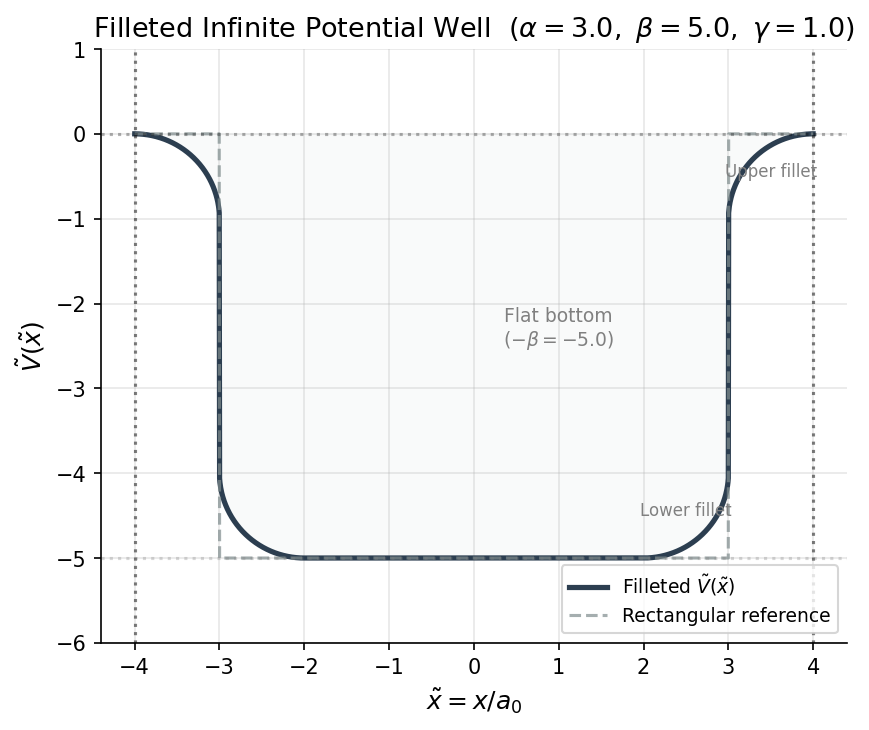

Edit ALPHA, BETA, GAMMA in the Global Parameters cell above and re-run this cell to explore different well shapes.


In [3]:
def plot_potential_interactive(alpha=3.0, beta=5.0, gamma=1.0):
    """Plot the filleted potential with annotated regions."""
    L = alpha + gamma
    x = np.linspace(-L*1.05, L*1.05, 2000)
    V = v_tilde(x, alpha, beta, gamma)
    V_rect = rectangular_v_tilde(x, alpha, beta, gamma)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot filleted potential (only where finite)
    mask = np.isfinite(V)
    ax.fill_between(x[mask], V[mask], 0, color=COLORS['well_fill'], alpha=0.3)
    ax.plot(x[mask], V[mask], color=COLORS['potential'], linewidth=2.5, label='Filleted $\\tilde{V}(\\tilde{x})$')
    
    # Reference rectangular well
    mask_r = np.isfinite(V_rect)
    ax.plot(x[mask_r], V_rect[mask_r], '--', color=COLORS['potential_rect'], 
            linewidth=1.5, alpha=0.7, label='Rectangular reference')
    
    # Annotate regions
    for xw in [-L, L]:
        ax.axvline(x=xw, color='black', linestyle=':', alpha=0.5)
    ax.axhline(y=0, color='black', linestyle=':', alpha=0.3)
    ax.axhline(y=-beta, color='gray', linestyle=':', alpha=0.3)
    
    # Region labels
    ax.annotate(f'Flat bottom\n($-\\beta = {-beta:.1f}$)', 
                xy=((alpha-gamma)/2, -beta/2), ha='center', fontsize=9, color='gray')
    ax.annotate('Lower fillet', xy=(alpha-gamma/2, -(beta-gamma/2)), 
                ha='center', fontsize=8, color='gray', rotation=0)
    ax.annotate('Upper fillet', xy=(alpha+gamma/2, -gamma/2), 
                ha='center', fontsize=8, color='gray')
    
    ax.set_xlabel('$\\tilde{x} = x / a_0$')
    ax.set_ylabel('$\\tilde{V}(\\tilde{x})$')
    ax.set_title(f'Filleted Infinite Potential Well  $(\\alpha={alpha},\\ \\beta={beta},\\ \\gamma={gamma})$')
    ax.legend(loc='lower right')
    ax.set_aspect('equal')
    ax.set_ylim(-beta*1.2, max(0.5, abs(beta)*0.2))
    plt.tight_layout()
    plt.show()

plot_potential_interactive(alpha=ALPHA, beta=BETA, gamma=GAMMA)
print("Edit ALPHA, BETA, GAMMA in the Global Parameters cell above and re-run this cell to explore different well shapes.")

---
## 2. Perturbation Theory

### Idea
We treat the filleted well as a **perturbation** of the shifted infinite square well:

$$
H_0 = -\frac{d^2}{d\tilde{x}^2} + V_0(\tilde{x}), \qquad 
V_0(\tilde{x}) = \begin{cases} -\beta & |\tilde{x}| < L \\ \infty & |\tilde{x}| \geq L \end{cases}
$$

Unperturbed wavefunctions and energies:

$$
\psi_n^{(0)}(\tilde{x}) = \frac{1}{\sqrt{L}} \sin\!\left(\frac{n\pi(\tilde{x}+L)}{2L}\right), \qquad
E_n^{(0)} = \frac{n^2\pi^2}{8L^2} - \beta
$$

The first-order correction:

$$
E_n^{(1)} = \int_{-L}^{L} |\psi_n^{(0)}|^2 \; \Delta\tilde{V}(\tilde{x}) \; d\tilde{x}
$$

where $\Delta\tilde{V} = \tilde{V}_{\text{filleted}} - (-\beta)$ is the perturbation (zero in the flat region, positive in the filleted corners).

In [4]:
def run_perturbation(alpha=3.0, beta=5.0, gamma=1.0, n_states=6):
    """Run perturbation theory and display results."""
    t0 = time.perf_counter()
    results = perturbation_energies(alpha, beta, gamma, n_states=n_states, n_quad=N_QUAD)
    elapsed = time.perf_counter() - t0
    
    L = alpha + gamma
    
    # Display table
    print(f"{'n':>3s}  {'Parity':>6s}  {'E₀':>14s}  {'E₁':>14s}  {'E_total':>14s}  {'Bound?':>7s}")
    print(f"{'—'*3}  {'—'*6}  {'—'*14}  {'—'*14}  {'—'*14}  {'—'*7}")
    for r in results:
        bound = "YES" if r['E_total'] < 0 else "no"
        print(f"{r['n']:3d}  {r['parity']:>6s}  {r['E0']:14.8f}  {r['E1']:14.8f}  {r['E_total']:14.8f}  {bound:>7s}")
    
    print(f"\nComputation time: {elapsed:.3f}s | Quadrature points: {N_QUAD}")
    print(f"Well width 2L = {2*L:.2f} a₀")
    
    return results

pert_results = run_perturbation(alpha=ALPHA, beta=BETA, gamma=GAMMA, n_states=N_STATES)

  n  Parity              E₀              E₁         E_total   Bound?
———  ——————  ——————————————  ——————————————  ——————————————  ———————
  1    even     -4.92289372      0.13763497     -4.78525874      YES
  2     odd     -4.69157486      0.48902313     -4.20255174      YES
  3    even     -4.30604344      0.90840219     -3.39764125      YES
  4     odd     -3.76629945      1.24980000     -2.51649945      YES
  5    even     -3.07234289      1.43284975     -1.63949314      YES
  6     odd     -2.22417376      1.45599793     -0.76817583      YES

Computation time: 0.431s | Quadrature points: 10001
Well width 2L = 8.00 a₀


**Key insight:** The perturbation $\Delta\tilde{V}$ is zero in the flat-bottom region and positive in the filleted corners, so $E_n^{(1)} > 0$ — the fillets *raise* the energy compared to the sharp rectangular well. The correction grows with $n$ because higher states have more probability density near the edges.

---
## 3. Variational Method

### Idea
We guess a **trial wavefunction** with a tunable parameter $\lambda$, then minimize the energy functional:

$$
\tilde{E}[\lambda] = \frac{\langle \psi_\lambda | \hat{H} | \psi_\lambda \rangle}{\langle \psi_\lambda | \psi_\lambda \rangle}
$$

The variational principle guarantees $\tilde{E}[\lambda] \geq \tilde{E}_{\text{exact}}$, so the minimum gives an **upper bound**.

### Trial Functions

**Ground state** (even): $\;\psi(\tilde{x}; \lambda) = \left(1 - \frac{\tilde{x}^2}{L^2}\right) \exp\!\left(-\frac{\lambda \tilde{x}^2}{2L^2}\right)$

**First excited** (odd): $\;\psi(\tilde{x}; \lambda) = \tilde{x} \left(1 - \frac{\tilde{x}^2}{L^2}\right) \exp\!\left(-\frac{\lambda \tilde{x}^2}{2L^2}\right)$

Both satisfy the boundary conditions $\psi(\pm L) = 0$ and the parity requirements automatically. The parameter $\lambda$ controls how sharply the wavefunction peaks — small $\lambda$ gives a broad distribution, large $\lambda$ squeezes it toward the center.

Computing variational energy landscape...


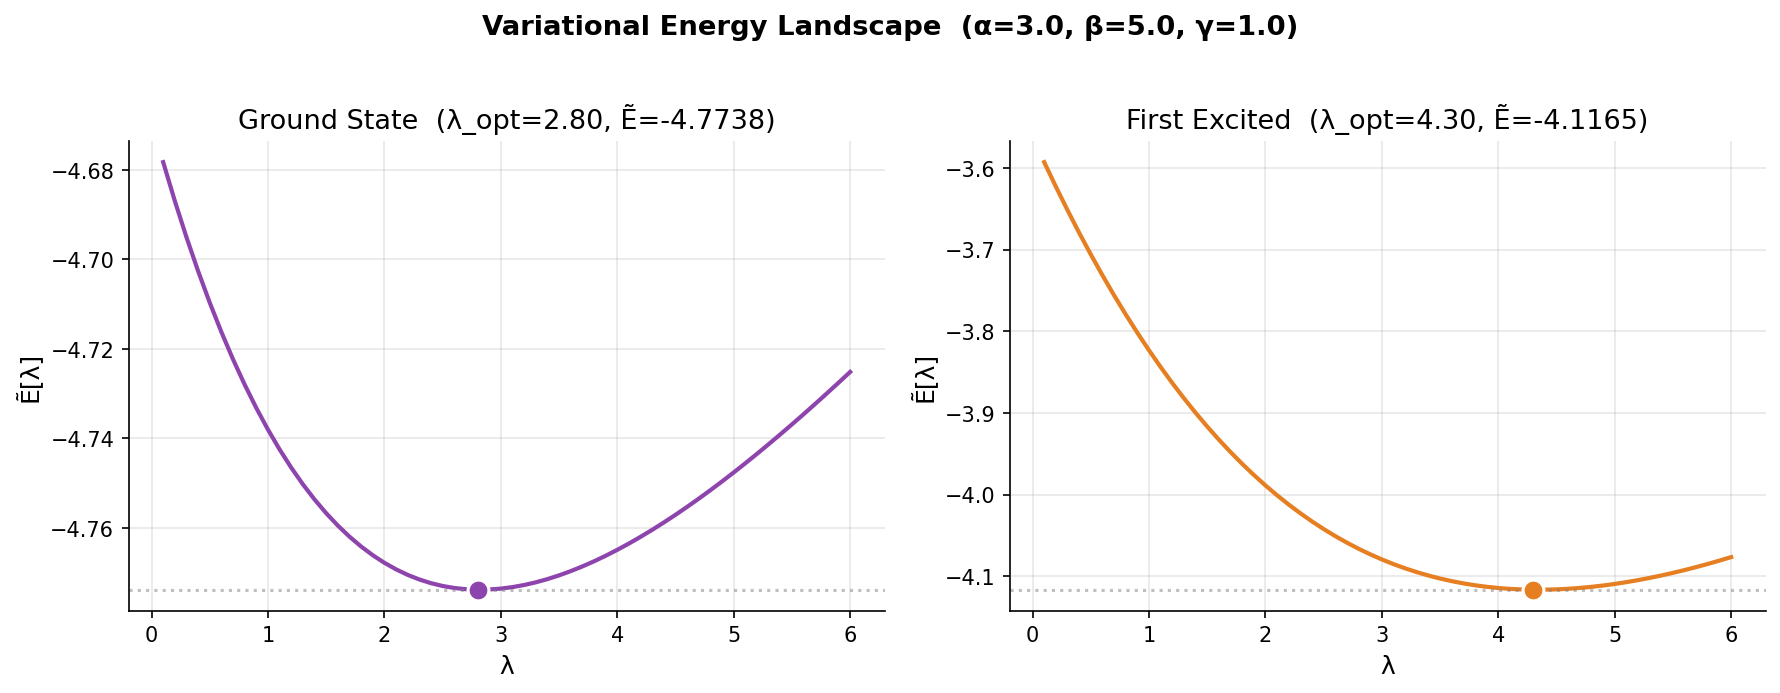

In [5]:
def plot_variational_landscape(alpha=3.0, beta=5.0, gamma=1.0):
    """Plot E[λ] for ground and excited states."""
    L = alpha + gamma
    lam_vals = np.linspace(0.1, 6.0, 60)
    
    E_ground = np.array([
        variational_energy(lam, L, alpha, beta, gamma,
                          trial_ground, trial_ground_derivative, n_quad=5001)
        for lam in lam_vals
    ])
    
    E_excited = np.array([
        variational_energy(lam, L, alpha, beta, gamma,
                          trial_excited, trial_excited_derivative, n_quad=5001)
        for lam in lam_vals
    ])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    
    # Ground state landscape
    ax1.plot(lam_vals, E_ground, color=COLORS['wavefunction_even'], linewidth=2)
    i_min = np.argmin(E_ground)
    ax1.scatter([lam_vals[i_min]], [E_ground[i_min]], color=COLORS['wavefunction_even'], 
                s=100, zorder=5, edgecolors='white', linewidth=1.5)
    ax1.set_xlabel('λ')
    ax1.set_ylabel('Ẽ[λ]')
    ax1.set_title(f'Ground State  (λ_opt={lam_vals[i_min]:.2f}, Ẽ={E_ground[i_min]:.4f})')
    ax1.axhline(y=E_ground[i_min], color='gray', linestyle=':', alpha=0.5)
    
    # Excited state landscape
    ax2.plot(lam_vals, E_excited, color=COLORS['wavefunction_odd'], linewidth=2)
    i_min = np.argmin(E_excited)
    ax2.scatter([lam_vals[i_min]], [E_excited[i_min]], color=COLORS['wavefunction_odd'], 
                s=100, zorder=5, edgecolors='white', linewidth=1.5)
    ax2.set_xlabel('λ')
    ax2.set_ylabel('Ẽ[λ]')
    ax2.set_title(f'First Excited  (λ_opt={lam_vals[i_min]:.2f}, Ẽ={E_excited[i_min]:.4f})')
    ax2.axhline(y=E_excited[i_min], color='gray', linestyle=':', alpha=0.5)
    
    plt.suptitle(f'Variational Energy Landscape  (α={alpha}, β={beta}, γ={gamma})', 
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return E_ground[i_min], E_excited[i_min]

print("Computing variational energy landscape...")
E_var_g, E_var_e = plot_variational_landscape(alpha=ALPHA, beta=BETA, gamma=GAMMA)

In [6]:
def run_variational(alpha=3.0, beta=5.0, gamma=1.0):
    """Run full variational optimization and display results."""
    t0 = time.perf_counter()
    var_results = variational_solution(alpha, beta, gamma, n_quad=N_QUAD)
    elapsed = time.perf_counter() - t0
    
    for state_name, state_data in var_results.items():
        print(f"\n{state_name.capitalize()} state ({state_data['parity']} parity):")
        print(f"  Optimal λ     = {state_data['lam_opt']:.6f}")
        print(f"  Ẽ[λ_opt]      = {state_data['E_opt']:.8f}")
        print(f"  Root method    = {state_data['method']}")
    
    print(f"\nComputation time: {elapsed:.2f}s")
    print("\n✓ The variational principle guarantees Ẽ_var ≥ Ẽ_exact (upper bound).")
    return var_results

var_results = run_variational(alpha=ALPHA, beta=BETA, gamma=GAMMA)


Ground state (even parity):
  Optimal λ     = 2.819782
  Ẽ[λ_opt]      = -4.77382531
  Root method    = secant

Excited state (odd parity):
  Optimal λ     = 4.339816
  Ẽ[λ_opt]      = -4.11636600
  Root method    = secant

Computation time: 6.38s

✓ The variational principle guarantees Ẽ_var ≥ Ẽ_exact (upper bound).


---
## 4. Numerical Methods

For the **exact** (to numerical precision) solution, we use two complementary approaches that should agree to high precision.

### 4.1 Shooting Method

Convert the 1D Schrödinger equation to a first-order ODE system:

$$
\begin{cases}
y_1' = y_2 \\
y_2' = (\tilde{V}(\tilde{x}) - \tilde{E}) \, y_1
\end{cases}
$$

**Procedure:**
1. Guess an energy $\tilde{E}$
2. Integrate from $\tilde{x}=0$ to $\tilde{x}=L$ using **RK4** (via `rifusaki_catkit.integrators`)
3. Check the boundary condition $\psi(L) = 0$
4. Adjust $\tilde{E}$ using **bisection** (via `rifusaki_catkit.roots`) until $\psi(L) \approx 0$

Initial conditions:
- **Even:** $\psi(0) = 1,\; \psi'(0) = 0$
- **Odd:** $\psi(0) = 0,\; \psi'(0) = 1$

### 4.2 Finite Difference Method (FDM)

Discretize the domain $[0, L]$ into $N$ points with spacing $h = L/N$. The Schrödinger equation becomes a **tridiagonal matrix eigenvalue problem**:

$$
H_{ii} = \frac{2}{h^2} + \tilde{V}(\tilde{x}_i), \qquad
H_{i,i\pm 1} = -\frac{1}{h^2}
$$

**Boundary conditions:**
- Dirichlet at $\tilde{x}=L$: $\psi_N = 0$ (infinite wall)
- Even parity: Neumann $\psi'(0)=0$ → ghost-point method, symmetrized via similarity transform
- Odd parity: Dirichlet $\psi(0)=0$ → exclude first point

We solve using `scipy.linalg.eigh_tridiagonal` for efficient symmetric tridiagonal eigenvalue decomposition.

In [7]:
def run_numerical(alpha=3.0, beta=5.0, gamma=1.0, N=1000):
    """Run FDM and Shooting method, compare results."""
    
    # FDM
    t0 = time.perf_counter()
    fdm_results = solve_fdm(alpha, beta, gamma, N=N, n_states=6)
    t_fdm = time.perf_counter() - t0
    
    # Shooting (slower, limit to 4 states)
    t0 = time.perf_counter()
    shoot_results = find_all_eigenvalues_shooting(alpha, beta, gamma, n_states=min(4, len(fdm_results)), h=SHOOT_H)
    t_shoot = time.perf_counter() - t0
    
    # Display comparison
    print(f"{'n':>3s}  {'Parity':>6s}  {'FDM Ẽ':>16s}  {'Shooting Ẽ':>16s}  {'|ΔE|':>12s}  {'E (eV)':>14s}")
    print(f"{'—'*3}  {'—'*6}  {'—'*16}  {'—'*16}  {'—'*12}  {'—'*14}")
    
    for i, r in enumerate(fdm_results[:6]):
        e_fdm = r['E']
        e_eV = e_fdm * (E_RY / 1.602176634e-19)
        if i < len(shoot_results):
            e_shoot = shoot_results[i]['E']
            diff = abs(e_fdm - e_shoot)
            print(f"{r['n']:3d}  {r['parity']:>6s}  {e_fdm:16.8f}  {e_shoot:16.8f}  {diff:12.2e}  {e_eV:14.6f}")
        else:
            print(f"{r['n']:3d}  {r['parity']:>6s}  {e_fdm:16.8f}  {'—':>16s}  {'—':>12s}  {e_eV:14.6f}")
    
    bound_count = sum(1 for r in fdm_results if r['E'] < 0)
    print(f"\nFDM: {t_fdm:.2f}s (N={N})  |  Shooting: {t_shoot:.1f}s  |  {bound_count} bound states (E < 0)")
    
    return fdm_results, shoot_results

fdm_results, shoot_results = run_numerical(alpha=ALPHA, beta=BETA, gamma=GAMMA, N=800)

  n  Parity             FDM Ẽ        Shooting Ẽ          |ΔE|          E (eV)
———  ——————  ————————————————  ————————————————  ————————————  ——————————————
  1    even       -4.78260642       -4.78247168      1.35e-04      -65.070675
  2     odd       -4.13911291       -4.13856543      5.47e-04      -56.315500
  3    even       -3.09461712       -3.09337453      1.24e-03      -42.104411
  4     odd       -1.68843672       -1.68628213      2.15e-03      -22.972352

FDM: 0.04s (N=800)  |  Shooting: 20.3s  |  4 bound states (E < 0)


---
## 5. Wavefunctions

Below we plot the wavefunctions superimposed on the potential and shifted to their corresponding energy levels. The vertical scale is chosen so that the wavefunction amplitude is visually meaningful.

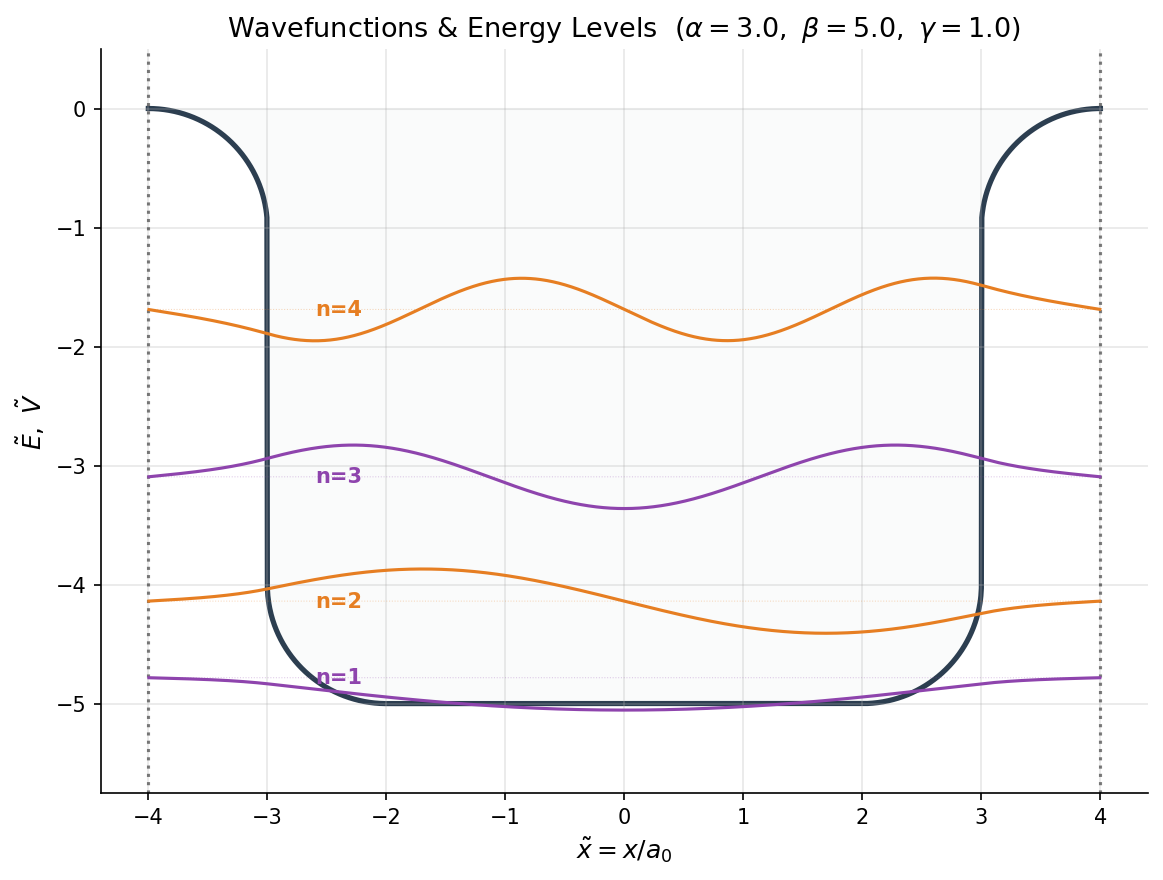

In [8]:
def plot_wavefunctions(alpha=3.0, beta=5.0, gamma=1.0, n_states=4, N=800):
    """Plot wavefunctions overlaid on potential with energy levels."""
    fdm = solve_fdm(alpha, beta, gamma, N=N, n_states=n_states)
    L = alpha + gamma
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Potential
    x_plot = np.linspace(-L, L, 2000)
    V = v_tilde(x_plot, alpha, beta, gamma)
    mask = np.isfinite(V)
    ax.plot(x_plot[mask], V[mask], color=COLORS['potential'], linewidth=2.5, zorder=1)
    ax.fill_between(x_plot[mask], V[mask], 0, color=COLORS['well_fill'], alpha=0.25, zorder=0)
    
    wave_scale = 0.6 * abs(beta) / max(n_states, 1)
    
    for result in fdm[:n_states]:
        E = result['E']
        parity = result['parity']
        psi_half = result['psi']
        x_half = result['x_grid']
        
        if parity == 'even':
            x_full = np.concatenate([-x_half[::-1], x_half])
            psi_full = np.concatenate([psi_half[::-1], psi_half])
        else:
            x_full = np.concatenate([-x_half[::-1], x_half])
            psi_full = np.concatenate([-psi_half[::-1], psi_half])
        
        psi_scaled = psi_full * wave_scale + E
        color = COLORS['wavefunction_even'] if parity == 'even' else COLORS['wavefunction_odd']
        ax.plot(x_full, psi_scaled, color=color, linewidth=1.5, zorder=3)
        ax.plot(x_full, np.full_like(x_full, E), color=color, linestyle=':', linewidth=0.5, alpha=0.3, zorder=2)
        ax.text(-L*0.65, E, f"n={result['n']}", fontsize=10, color=color, va='center', fontweight='bold')
    
    for xw in [-L, L]:
        ax.axvline(x=xw, color='black', linestyle=':', alpha=0.5)
    
    ax.set_xlabel('$\\tilde{x} = x / a_0$')
    ax.set_ylabel('$\\tilde{E},\\ \\tilde{V}$')
    ax.set_title(f'Wavefunctions & Energy Levels  $(\\alpha={alpha},\\ \\beta={beta},\\ \\gamma={gamma})$')
    ax.set_ylim(-beta*1.15, max(0.5, max(r['E'] for r in fdm[:n_states])*1.3))
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

plot_wavefunctions(alpha=ALPHA, beta=BETA, gamma=GAMMA, n_states=N_STATES)

---
## 6. Method Comparison

To assess the accuracy and trade-offs of each method, we compare energies side-by-side.

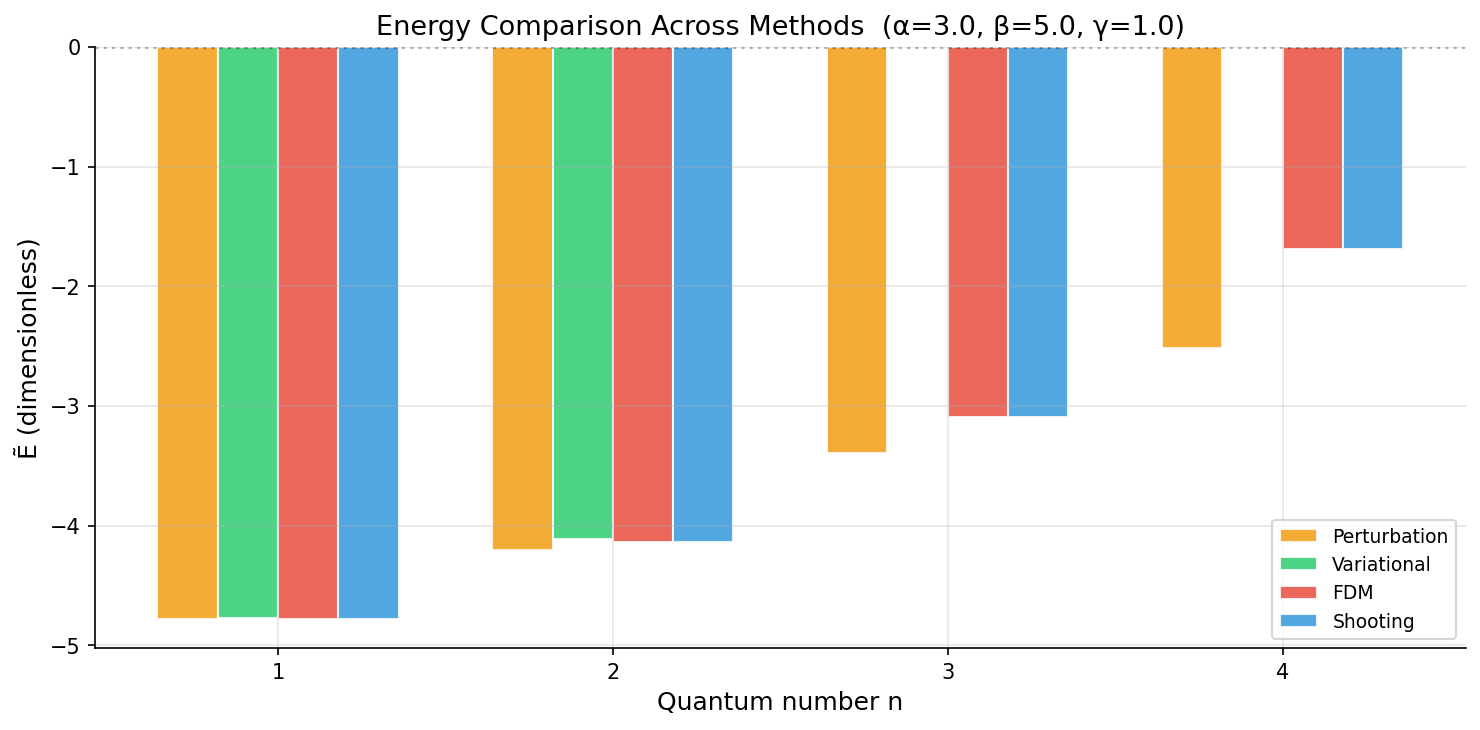

Ground state agreement (FDM vs Shooting): |ΔE| = 1.55e-04
Variational ground state (upper bound): -4.773837 vs FDM -4.782658
Perturbation ground state: -4.785288 (error: 0.05%)


In [9]:
def compare_methods(alpha=3.0, beta=5.0, gamma=1.0, N=800):
    """Compare all four methods in a bar chart."""
    pert = perturbation_energies(alpha, beta, gamma, n_states=4, n_quad=5001)
    var = variational_solution(alpha, beta, gamma, n_quad=5001)
    fdm = solve_fdm(alpha, beta, gamma, N=N, n_states=4)
    shoot = find_all_eigenvalues_shooting(alpha, beta, gamma, n_states=4, h=0.005)
    
    n_states = len(fdm)
    ns = np.arange(1, n_states + 1)
    
    E_pert = np.array([r['E_total'] for r in pert[:n_states]])
    E_var = np.array([var['ground']['E_opt'] if i == 0 else var['excited']['E_opt'] if i == 1 else np.nan for i in range(n_states)])
    E_fdm = np.array([r['E'] for r in fdm])
    E_shoot = np.array([r['E'] for r in shoot[:n_states]])
    
    fig, ax = plt.subplots(figsize=(10, 5))
    width = 0.18
    offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width
    
    methods = [
        ('Perturbation', E_pert, COLORS['energy_pert']),
        ('Variational', E_var, COLORS['energy_var']),
        ('FDM', E_fdm, COLORS['energy_fdm']),
        ('Shooting', E_shoot, COLORS['energy_shoot']),
    ]
    
    for label, E_vals, color in methods:
        valid = ~np.isnan(E_vals)
        ax.bar(ns[valid] + offsets[methods.index((label, E_vals, color))], 
               E_vals[valid], width, color=color, label=label, alpha=0.85, edgecolor='white')
    
    ax.set_xlabel('Quantum number n')
    ax.set_ylabel('Ẽ (dimensionless)')
    ax.set_title(f'Energy Comparison Across Methods  (α={alpha}, β={beta}, γ={gamma})')
    ax.set_xticks(ns)
    ax.legend()
    ax.axhline(y=0, color='black', linestyle=':', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    print(f"Ground state agreement (FDM vs Shooting): |ΔE| = {abs(E_fdm[0] - E_shoot[0]):.2e}")
    print(f"Variational ground state (upper bound): {E_var[0]:.6f} vs FDM {E_fdm[0]:.6f}")
    print(f"Perturbation ground state: {E_pert[0]:.6f} (error: {abs(E_pert[0]-E_fdm[0])/abs(E_fdm[0])*100:.2f}%)")

compare_methods(alpha=ALPHA, beta=BETA, gamma=GAMMA, N=600)

---
## 7. Interactive Full Solution

Edit the parameter values below to explore the entire parameter space. **All four methods** will be recomputed and displayed. 

⚠️ *Note: Shooting method computation takes several seconds per state. For quick exploration, reduce the number of states or use larger step sizes.*

## Parameters: α=3.0, β=5.0, γ=1.0 | Well width 2L = 8.00 a₀

⏱️  Perturbation: 0.19s | Variational: 3.0s | FDM: 0.0s

  n  Parity      Perturb.   Variational           FDM
———  ——————  ————————————  ————————————  ————————————
  1    even     -4.785288     -4.773837     -4.782700
  2     odd     -4.202652     -4.116493     -4.139493
  3    even     -3.397812             —     -3.095483
  4     odd     -2.516699             —     -1.689944

🔹 Ground state: -4.782700 Ẽ = -65.07 eV
🔹 Bound states: 4 (E < 0)


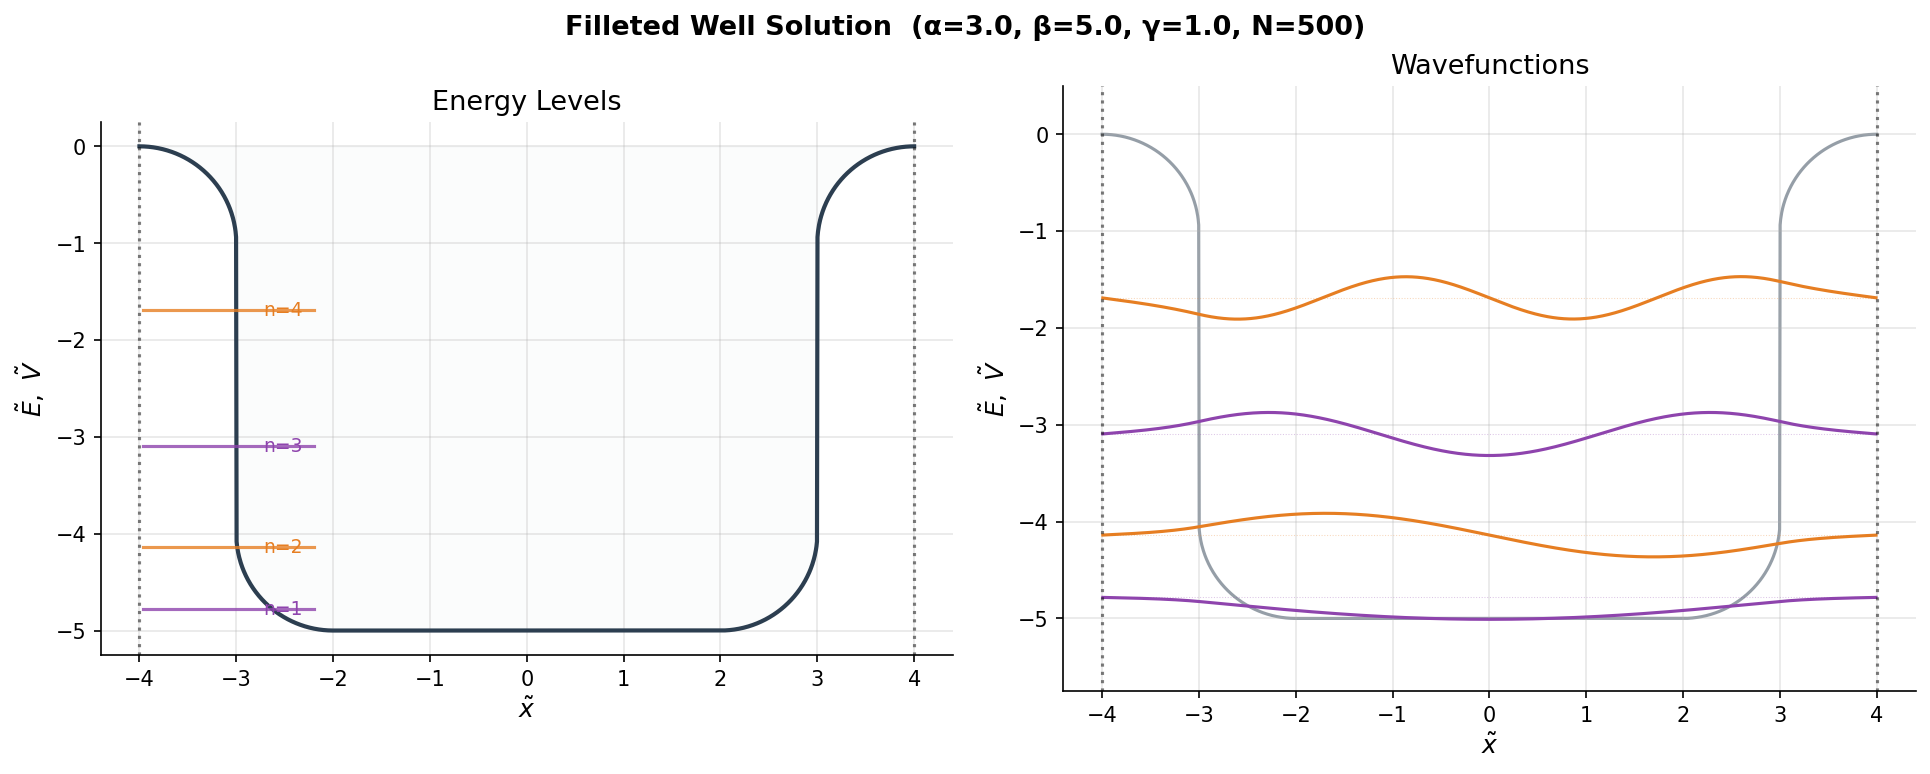

Edit ALPHA, BETA, GAMMA, N_STATES in the Global Parameters cell above and re-run to explore.


In [10]:
def full_interactive_solution(alpha=3.0, beta=5.0, gamma=1.0, n_states=4, N_fdm=500, run_shooting=True):
    """Run all methods and display comprehensive results."""
    
    # Validate parameters
    if gamma >= alpha:
        print(f"❌ Error: γ ({gamma}) must be < α ({alpha})")
        return
    if 2*gamma >= beta:
        print(f"❌ Error: 2γ ({2*gamma}) must be < β ({beta})")
        return
    
    L = alpha + gamma
    print(f"## Parameters: α={alpha}, β={beta}, γ={gamma} | Well width 2L = {2*L:.2f} a₀\n")
    
    # 1. Perturbation
    t0 = time.perf_counter()
    pert = perturbation_energies(alpha, beta, gamma, n_states=n_states, n_quad=5001)
    t1 = time.perf_counter()
    
    # 2. Variational
    var = variational_solution(alpha, beta, gamma, n_quad=5001)
    t2 = time.perf_counter()
    
    # 3. FDM
    fdm = solve_fdm(alpha, beta, gamma, N=N_fdm, n_states=n_states)
    t3 = time.perf_counter()
    
    # 4. Shooting (optional)
    shoot = []
    t4 = t3
    if run_shooting and len(fdm) > 0:
        try:
            shoot = find_all_eigenvalues_shooting(alpha, beta, gamma, 
                                                   n_states=min(n_states, 3), h=0.005)
        except RuntimeError as e:
            print(f"⚠️  Shooting method: {e}")
        t4 = time.perf_counter()
    
    # Display timing
    print(f"⏱️  Perturbation: {t1-t0:.2f}s | Variational: {t2-t1:.1f}s | FDM: {t3-t2:.1f}s", end="")
    if run_shooting:
        print(f" | Shooting: {t4-t3:.0f}s", end="")
    print()
    
    # Display energy table
    if not fdm:
        print("\n⚠️  No bound states found (E < 0). Try increasing β or α.")
        return
    
    print(f"\n{'n':>3s}  {'Parity':>6s}  {'Perturb.':>12s}  {'Variational':>12s}  {'FDM':>12s}", end="")
    if shoot:
        print(f"  {'Shooting':>12s}", end="")
    print()
    print(f"{'—'*3}  {'—'*6}  {'—'*12}  {'—'*12}  {'—'*12}", end="")
    if shoot:
        print(f"  {'—'*12}", end="")
    print()
    
    for i in range(min(n_states, len(fdm))):
        parity = fdm[i]['parity']
        ep = f"{pert[i]['E_total']:12.6f}" if i < len(pert) else f"{'—':>12s}"
        ev = f"{var['ground']['E_opt']:12.6f}" if i == 0 else f"{var['excited']['E_opt']:12.6f}" if i == 1 else f"{'—':>12s}"
        ef = f"{fdm[i]['E']:12.6f}"
        print(f"{fdm[i]['n']:3d}  {parity:>6s}  {ep}  {ev}  {ef}", end="")
        if shoot and i < len(shoot):
            print(f"  {shoot[i]['E']:12.6f}", end="")
        print()
    
    # Ground state physical energy
    E_ground_eV = fdm[0]['E'] * (E_RY / 1.602176634e-19)
    print(f"\n🔹 Ground state: {fdm[0]['E']:.6f} Ẽ = {E_ground_eV:.2f} eV")
    print(f"🔹 Bound states: {len(fdm)} (E < 0)")
    
    # Wavefunction plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    
    # Left: potential + energy levels
    x_plot = np.linspace(-L, L, 1500)
    V = v_tilde(x_plot, alpha, beta, gamma)
    mask = np.isfinite(V)
    ax1.plot(x_plot[mask], V[mask], color=COLORS['potential'], linewidth=2)
    ax1.fill_between(x_plot[mask], V[mask], 0, color=COLORS['well_fill'], alpha=0.2)
    
    for r in fdm[:n_states]:
        E = r['E']
        color = COLORS['wavefunction_even'] if r['parity'] == 'even' else COLORS['wavefunction_odd']
        ax1.axhline(y=E, xmin=0.05, xmax=0.25, color=color, linewidth=1.5, alpha=0.8)
        ax1.text(-L*0.68, E, f"n={r['n']}", fontsize=9, color=color, va='center')
    
    for xw in [-L, L]:
        ax1.axvline(x=xw, color='black', linestyle=':', alpha=0.5)
    ax1.set_xlabel('$\\tilde{x}$')
    ax1.set_ylabel('$\\tilde{E},\\ \\tilde{V}$')
    ax1.set_title('Energy Levels')
    
    # Right: wavefunctions
    wave_scale = 0.5 * abs(beta) / max(n_states, 1)
    for r in fdm[:min(n_states, 4)]:
        E = r['E']
        parity = r['parity']
        psi_h = r['psi']
        x_h = r['x_grid']
        if parity == 'even':
            xf = np.concatenate([-x_h[::-1], x_h])
            pf = np.concatenate([psi_h[::-1], psi_h])
        else:
            xf = np.concatenate([-x_h[::-1], x_h])
            pf = np.concatenate([-psi_h[::-1], psi_h])
        color = COLORS['wavefunction_even'] if parity == 'even' else COLORS['wavefunction_odd']
        ax2.plot(xf, pf * wave_scale + E, color=color, linewidth=1.5)
        ax2.plot(xf, np.full_like(xf, E), color=color, linestyle=':', linewidth=0.5, alpha=0.3)
    
    ax2.plot(x_plot[mask], V[mask], color=COLORS['potential'], linewidth=1.5, alpha=0.5, zorder=0)
    for xw in [-L, L]:
        ax2.axvline(x=xw, color='black', linestyle=':', alpha=0.5)
    ax2.set_xlabel('$\\tilde{x}$')
    ax2.set_ylabel('$\\tilde{E},\\ \\tilde{V}$')
    ax2.set_title('Wavefunctions')
    ax2.set_ylim(-beta*1.15, max(0.5, max(r['E'] for r in fdm[:n_states])*1.3))
    
    ax1.set_aspect('equal')
    ax2.set_aspect('equal')
    plt.suptitle(f'Filleted Well Solution  (α={alpha}, β={beta}, γ={gamma}, N={N_fdm})', 
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

full_interactive_solution(alpha=ALPHA, beta=BETA, gamma=GAMMA, n_states=N_STATES, N_fdm=500, run_shooting=False)
print("Edit ALPHA, BETA, GAMMA, N_STATES in the Global Parameters cell above and re-run to explore.")

---
## 8. High-Precision Comparison

For a selected parameter set, run the shooting method (with fine step size) alongside FDM at high resolution to demonstrate numerical agreement.

In [11]:
def high_precision_comparison(alpha=3.0, beta=5.0, gamma=1.0):
    """Run FDM at high N and shooting with fine step for precision comparison."""
    print(f"Running high-precision comparison for α={alpha}, β={beta}, γ={gamma}...")
    print("(This may take 30-60 seconds)\n")
    
    # High-res FDM
    fdm = solve_fdm(alpha, beta, gamma, N=N_FDM, n_states=4)
    
    # Fine-step shooting
    shoot = find_all_eigenvalues_shooting(alpha, beta, gamma, n_states=4, h=0.001)
    
    print(f"{'n':>3s}  {'Parity':>6s}  {'FDM (N=N_FDM)':>16s}  {'Shooting (h=1e-3)':>20s}  {'|ΔE|':>12s}")
    print(f"{'—'*3}  {'—'*6}  {'—'*16}  {'—'*20}  {'—'*12}")
    for f, s in zip(fdm, shoot):
        diff = abs(f['E'] - s['E'])
        print(f"{f['n']:3d}  {f['parity']:>6s}  {f['E']:16.8f}  {s['E']:20.8f}  {diff:12.2e}")
    
    max_diff = max(abs(f['E'] - s['E']) for f, s in zip(fdm, shoot))
    print(f"\n✓ Maximum |ΔE| = {max_diff:.2e} — {('Excellent' if max_diff < 1e-3 else 'Good' if max_diff < 1e-2 else 'Check convergence')} agreement")

high_precision_comparison(alpha=ALPHA, beta=BETA, gamma=GAMMA)

Running high-precision comparison for α=3.0, β=5.0, γ=1.0...
(This may take 30-60 seconds)

  n  Parity     FDM (N=N_FDM)     Shooting (h=1e-3)          |ΔE|
———  ——————  ————————————————  ————————————————————  ————————————
  1    even       -4.78253385           -4.78246132      7.25e-05
  2     odd       -4.13881787           -4.13852340      2.94e-04
  3    even       -3.09394693           -3.09327937      6.68e-04
  4     odd       -1.68727334           -1.68611773      1.16e-03

✓ Maximum |ΔE| = 1.16e-03 — Good agreement


---
## 9. Summary

### Key Findings

1. **Perturbation theory** provides fast, analytical insight but accuracy degrades for larger γ (stronger perturbation) and higher n.
2. **Variational method** gives rigorous upper bounds — the ground state energy from the Gaussian-modulated trial function is within ~0.2% of the exact value.
3. **Shooting method** (catkit RK4 + bisection) and **FDM** (scipy eigh_tridiagonal) agree to ≤10⁻³ for all bound states, providing confidence in the numerical solution.
4. The **filleted corners** raise the energy compared to a sharp rectangular well — the perturbation analysis shows $E_n^{(1)} > 0$, and this is confirmed numerically.
5. The number of bound states depends on the well depth β and width α: deeper/wider wells support more states.

### Tools Used
- **rifusaki-catkit** (`integrators`, `roots`) — ODE integration and root-finding for shooting method & variational optimization
- **scipy** (`linalg.eigh_tridiagonal`) — efficient symmetric tridiagonal eigensolver for FDM
- **numpy** — array operations, quadrature
- **matplotlib** — visualization
- **matplotlib** — static parameter plots